# Agent 1: Poor Contact Expert (접촉불량 전문가)

In [1]:
# Poor Contact Expert Graph Init
import sys
import os
from pathlib import Path
import json
import time

# 프로젝트 루트 경로 설정
project_root = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
sys.path.insert(0, str(project_root))

# 환경 변수 로드
from dotenv import load_dotenv
load_dotenv(project_root / ".env")

print(f"✓ 프로젝트 루트: {project_root}")
# 2. 테스트 이미지 준비
from src.utils import find_data_directory
from src.tools.experts.expert_utils import save_bytes_to_temp_file

from src.prompts.contact_expert_prompts import get_final_verdict_prompt
from src.tools.experts.expert_utils import call_gemini_text, parse_json_response
try:
    data_dir = find_data_directory()
    # 테스트할 이미지 파일명 (필요시 변경)
    test_image_name = "Poor_Contact_001.jpg" 
    test_image_path = Path(data_dir) / test_image_name
    
    if not test_image_path.exists():
        image_files = list(Path(data_dir).glob("*.png")) + list(Path(data_dir).glob("*.jpg"))
        if image_files:
            test_image_path = image_files[0]
            print(f"⚠️ 지정된 이미지를 찾을 수 없어 {test_image_path.name}을 사용합니다.")
        else:
            raise FileNotFoundError("테스트할 이미지가 없습니다.")
            
    print(f"✓ 테스트 이미지: {test_image_path}")
    
    with open(test_image_path, 'rb') as f:
        image_data = f.read()
    temp_image_path = save_bytes_to_temp_file(image_data)
    print(f"✓ 임시 이미지 경로: {temp_image_path}")
    
except Exception as e:
    print(f"❌ 오류: {e}")
# 3. Hotspot 탐지 (메인 그래프와 동일한 방식)
from src.nodes.common_nodes import hotspot_detector_node
from src.state import InvestigationState

print("✓ Hotspot 탐지 중...")
# hotspot_detector_node는 InvestigationState를 받으므로 임시 State 생성
temp_investigation_state = InvestigationState(
    payload=[],
    image_path=temp_image_path,
    hotspots=None,
    expert_reports=[],
    expert_analysis_results={},
    expert_confidence_scores={},
    expert_evidence={},
    final_verdict=None,
    errors=[]
)
hotspot_result = hotspot_detector_node(temp_investigation_state)
detected_hotspots = hotspot_result.get("hotspots", [])
print(f"✓ 탐지된 Hotspots: {len(detected_hotspots)}개")

# 4. 그래프 빌드 및 상태 초기화 (실행 전 필수)
from src.graphs.contact_expert_graph import build_contact_expert_graph
from src.nodes.contact_nodes import ContactExpertState

print("✓ 그래프 빌드 및 초기 상태 생성 중...")

initial_state = ContactExpertState(
    messages=[],
    image_path=temp_image_path,
    hotspots=detected_hotspots,  # 탐지된 hotspots 사용
    hotspot_queue=None,
    analysis_results=[],
    # Loop 변수 초기화
    current_hotspot=None,
    detector_result=None,
    roi_image_path=None,
    connection_type=None,
    terminal_result=None,
    splice_result=None,
    plug_result=None,
    verdict_report=None,
    verdict_confidence=None,
    verdict_result=None
)

graph = build_contact_expert_graph()
print("✓ 완료: initial_state 및 graph 객체 준비됨")

✓ 프로젝트 루트: c:\Users\loidn\Documents\Projects\P_04_Scope
✓ 테스트 이미지: c:\Users\loidn\Documents\Projects\P_04_Scope\data\Poor_Contact_001.jpg
✓ 임시 이미지 경로: C:\Users\loidn\AppData\Local\Temp\tmpwlmjzny9.jpg
✓ Hotspot 탐지 중...
📂 [Hotspot Detector] 이미지 경로 감지: C:\Users\loidn\AppData\Local\Temp\tmpwlmjzny9.jpg

📡 [Hotspot Detector] 다중 발화 지점 탐색 시작... (이미지: C:\Users\loidn\AppData\Local\Temp\tmpwlmjzny9.jpg)
📋 [Hotspot Detector] Finish reason: FinishReason.STOP

💭 [Hotspot Detector] 모델 응답 텍스트:
------------------------------------------------------------
📝 [Thinking 과정 (SDK Extracted)]:
**Fire Scene Analysis: Objective Assessment**

Alright, let's break this down. As a world-class fire investigation expert, my process is entirely objective. No room for emotion or subjective interpretations here. I'm going to leverage my extensive knowledge to analyze this scene meticulously, sticking to my defined protocol.

First, I'll assess the image quality. While generally clear, some areas lack the fine macro d

c:\Users\loidn\Documents\Projects\P_04_Scope\venv\Lib\site-packages\torchvision\transforms\functional_tensor.py:5: UserWarning: The torchvision.transforms.functional_tensor module is deprecated in 0.15 and will be **removed in 0.17**. Please don't rely on it. You probably just need to use APIs in torchvision.transforms.functional or in torchvision.transforms.v2.functional.
  warnings.warn(


Multi-Hotspot Loop 전체 실행 (Deform Specialist)

⚖️ [Hotspot Manager] Hotspot 우선순위 정렬 및 Top-N 선별
✅ 선별된 Hotspots: [3, 5, 4, 1, 2]

▶️ [Hotspot Manager] Processing Hotspot ID 3 (Potential Melted Bead Formation (잠재적 용융 망울 형성))
✂️ [ROI Crop] Hotspot 영역 크롭... [105, 495, 215, 615]
✨ [Enhancement] ROI 이미지 2배 향상 적용 중...
✨ [Enhancement] 향상 완료: C:\Users\loidn\AppData\Local\Temp\roi_crop_t1kt0n95.jpg

🔍 [Component Classifier] 부품 유형 식별 중... (Dual Input: Context + Detail, ROI: C:\Users\loidn\AppData\Local\Temp\roi_crop_t1kt0n95.jpg)
👁️ [Observation] 여러 가닥의 전선(도체) 끝부분이 한데 모여 있으며, 그 지점을 검게 탄화된 뭉툭하고 둥근 덩어리가 감싸고 있는 형태임. 전선 노출 부위에는 녹색의 산화 흔적이 관찰됨.
✅ 판별 결과: Splice (신뢰도: 85%)

⚡ [Contact] Splice Analysis (Dual Input: Context + Detail)
📋 [Contact Splice Specialist] Finish reason: FinishReason.STOP

💭 [Contact Splice Specialist] 모델 응답 텍스트:
------------------------------------------------------------
📝 [Thinking 과정 (SDK Extracted)]:
**Fire Scene Analysis: Suspected Poor Contact**

Alright, let's break this down

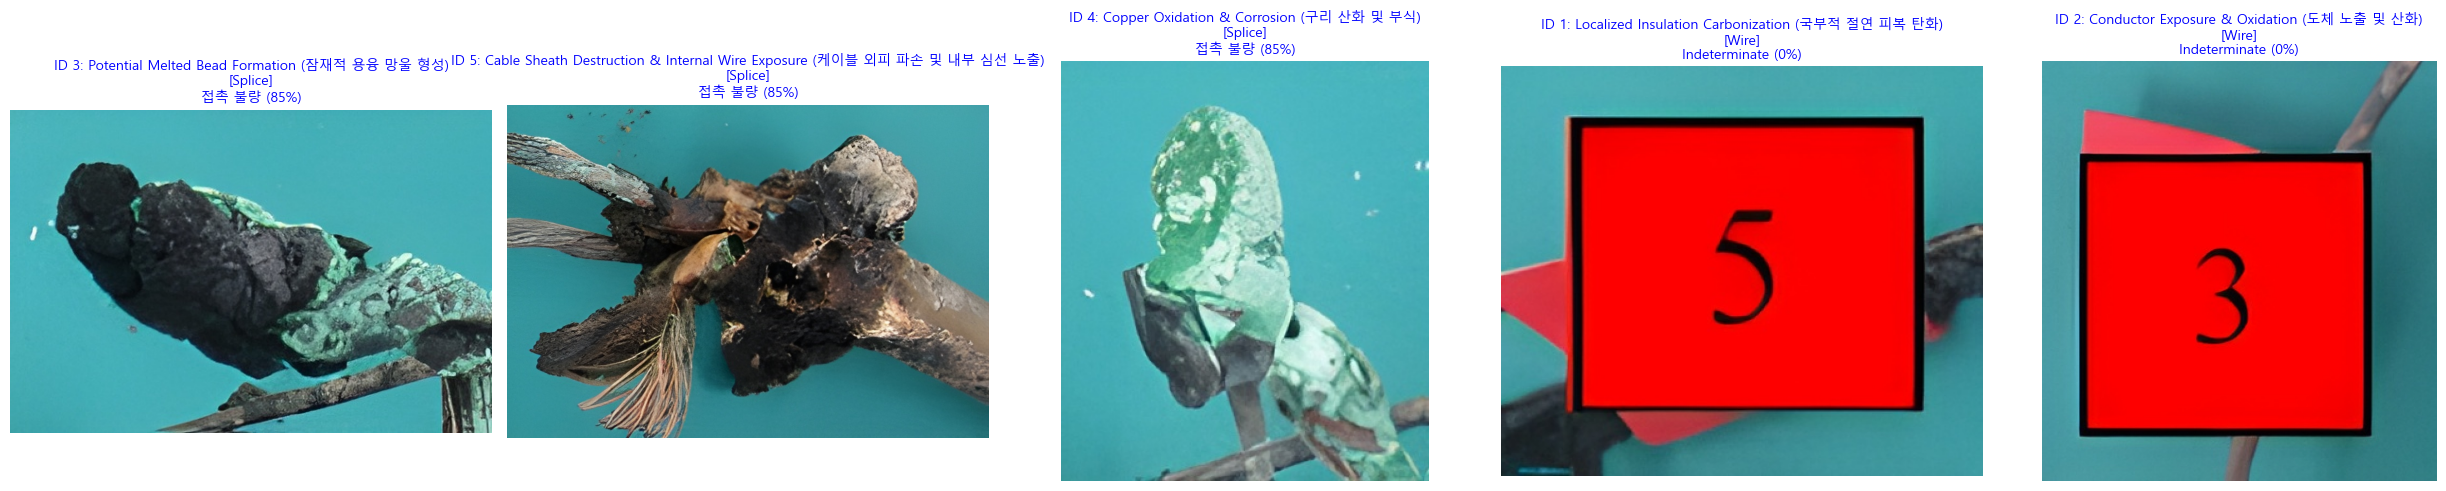

In [2]:
# Poor Contact Expert Graph Run

from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

print("=" * 60)
print("Multi-Hotspot Loop 전체 실행 (Deform Specialist)")
print("=" * 60)

start_time = time.time()
try:
    # Recursion Limit을 넉넉히 주어야 Loop가 돕니다.
    final_state = graph.invoke(initial_state, config={"recursion_limit": 50})
    elapsed = time.time() - start_time
    
    print(f"\n✓ 전체 실행 완료 (소요시간: {elapsed:.2f}초)")
    
    # 분석된 결과들 가져오기
    analysis_results = final_state.get("analysis_results", [])
    
    # 한글 폰트 설정 (Windows)
    try:
        # Windows에서 사용 가능한 한글 폰트 찾기
        font_list = ['Malgun Gothic', 'NanumGothic', 'NanumBarunGothic', 'Gulim', 'Batang']
        font_found = None
        for font_name in font_list:
            try:
                font_path = fm.findfont(fm.FontProperties(family=font_name))
                if font_path:
                    plt.rcParams['font.family'] = font_name
                    font_found = font_name
                    break
            except:
                continue
        
        if font_found:
            print(f"✓ 한글 폰트 설정: {font_found}")
        else:
            # 폰트를 찾지 못한 경우 경고만 출력하고 계속 진행
            print("⚠️ 한글 폰트를 찾을 수 없습니다. 한글이 제대로 표시되지 않을 수 있습니다.")
    except Exception as e:
        print(f"⚠️ 폰트 설정 중 오류: {e}")
    
    if not analysis_results:
        print("No analyzed images found.")
    else:
        num_images = len(analysis_results)
        if num_images > 0:
            # 서브플롯 크기 및 배열 설정
            cols = min(num_images, 5)
            rows = (num_images - 1) // cols + 1
            fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
            
            # axes가 단일 객체이거나 1차원 배열일 경우 처리
            if num_images == 1:
                axes = [axes]
            elif rows > 1:
                axes = axes.flatten()
            
            # 빈 서브플롯 숨기기
            if hasattr(axes, '__len__') and len(axes) > num_images:
                for ax in axes[num_images:]:
                    ax.axis('off')
            
            for idx, res in enumerate(analysis_results):
                # Data Extraction optimized for Deform Expert
                h_info = res.get('hotspot_info', {})
                hotspot_id = h_info.get('id', '?')
                feature = h_info.get('damage_type', 'Unknown')
                conn_type = res.get('connection_type', 'N/A')
                
                roi_path = res.get('roi_image_path')
                
                # Specialist Result Extraction
                # Deform Expert도 'specialist_result' 필드를 사용
                spec_res = res.get('specialist_result', {}) or {}
                
                verdict = spec_res.get('verdict', 'Indeterminate')
                # 긴 Verdict 문자열 줄임 처리
                if len(verdict) > 20: 
                    verdict = verdict.split('(')[0].strip() # 괄호 앞부분만 사용
                    
                conf = spec_res.get('confidence', 0)
                
                ax = axes[idx]
                
                if roi_path and os.path.exists(roi_path):
                    try:
                        img = Image.open(roi_path)
                        ax.imshow(img)
                        # Title 구성: ID, 판정 결과, 신뢰도
                        title_text = f"ID {hotspot_id}: {feature}\n[{conn_type}]\n{verdict} ({conf}%)"
                            
                        # Deform Expert 판정에 따른 색상
                        # 압착(Compression), 절단(Cut), 내부폭발(Internal) 등의 키워드에 따라 색상 구분
                        if "Compression" in verdict or "Crushing" in verdict or "Cut" in verdict or "Imprint" in verdict:
                             title_color = 'red' # 명확한 기계적 변형
                        elif "Internal" in verdict or "Explosion" in verdict:
                             title_color = 'purple' # 내부 요인
                        elif "Thermal" in verdict or "Melt" in verdict:
                             title_color = 'orange' # 열변형
                        else:
                             title_color = 'blue'

                        ax.set_title(title_text, fontsize=10, color=title_color)
                    except Exception as e:
                        ax.text(0.5, 0.5, "Error Loading", ha='center')
                        print(f"Error loading image {roi_path}: {e}")
                else:
                    ax.text(0.5, 0.5, "Image Not Found", ha='center')
                    ax.set_title(f"ID {hotspot_id}")
                    
                ax.axis('off')
            
            plt.tight_layout()
            plt.show()

except Exception as e:
    print(f"❌ 실행 중 오류: {e}")
    import traceback
    traceback.print_exc()